Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 564.2538 - mae: 21.8251
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 463.9158 - mae: 19.3124 
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 326.4754 - mae: 15.6123 
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 166.3735 - mae: 10.5093 
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 73.8807 - mae: 6.6024  
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 45.4237 - mae: 5.0198  
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 34.3892 - mae: 4.3880 
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 29.7044 - mae: 4.1174 
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 26.8455 - mae: 3.9202  
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 24.9777 - mae: 3.7604 
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 23.5206 - mae: 3.6643 
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 22.1259 - mae: 3.5259  
Epoch 13/

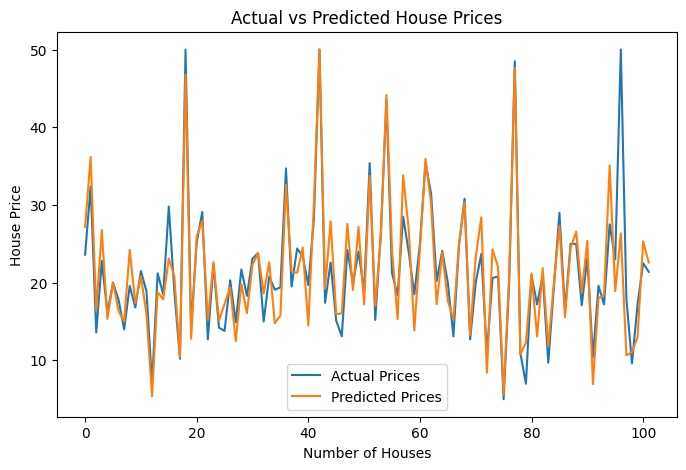

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# Load Dataset
data = pd.read_csv(r"C://Users//HP//Downloads//archive//HousingData.csv")

# Fill missing values
data = data.fillna(data.mean())

# Features and Target
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build Deep Neural Network Model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train Model
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=1
)

# Evaluate Model
loss, mae = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test MAE:", mae)

# Predict Prices
predicted_prices = model.predict(X_test)

# Print First Prediction
print("\nPredicted Price:", predicted_prices[0][0])
print("Actual Price:", y_test.iloc[0])

# Actual vs Predicted Graph
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label='Actual Prices')
plt.plot(predicted_prices, label='Predicted Prices')

plt.xlabel("Number of Houses")
plt.ylabel("House Price")
plt.title("Actual vs Predicted House Prices")

plt.legend()
plt.show()